<a href="https://colab.research.google.com/github/IsaacBFine/diabetes-predictors/blob/main/plsr_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PLSR Notebook
LASSO gave us a good baseline by indicating which variables held predictive power independent of other variables. However, based on our prior knowledge, we expected that there would exist interactions between the indicators themselves and wanted to explore that further using PLSR.




In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/IsaacBFine/diabetes-predictors/refs/heads/main/Data/clean/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"

data = pd.read_csv(url)
data.head()
#Loads in dataset


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt
import random
random.seed(67)
import numpy as np
np.random.seed(67)
from sklearn.preprocessing import StandardScaler

In [ ]:
#Split data into indicators and diabetes outcome.

X = data.drop(columns = ["Diabetes_binary"])
Y = data["Diabetes_binary"]

# Exploratory Work

1. Normalize data

In [ ]:
# Split data into training (80%) and testing (20%) sets
# random_state=67 ensures reproducibility and that we can debug with tests
# stratify=Y preserves the same 50/50 diabetes ratio in both train and test sets

scaler = StandardScaler()

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=67, stratify=Y)

In [ ]:
# normalize data so binary and continuous variables have equal weight

X_train_scaled = scaler.fit_transform(X_train)  # learn scale from train data and apply it
X_test_scaled = scaler.transform(X_test)        # apply same scale to test data

2. Identify the number of components to use for PLSR based on Q2Y

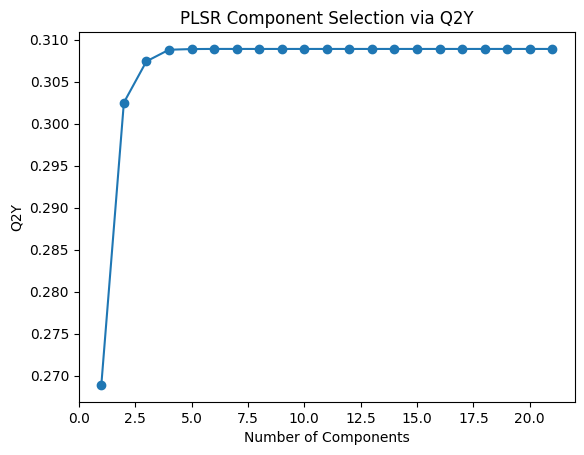

Best number of components: 6


In [ ]:
# test each number of components and calculate Q2Y score
q2y_scores = []
components = range(1, 22)

for n in components:
    pls = PLSRegression(n_components=n)
    scores = cross_val_score(pls, X_train_scaled, Y_train, cv=5, scoring='r2')
    q2y_scores.append(scores.mean())

# plot to visually find the elbow
plt.plot(components, q2y_scores, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Q2Y')
plt.title('PLSR Component Selection via Q2Y')
plt.show()

# pick the best number
best_n = components[np.argmax(q2y_scores)]
print(f"Best number of components: {best_n}")


/tmp/ipykernel_11296/1512627218.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate('Diabetes', (y_loadings['Component 5'][0], y_loadings['Component 6'][0]), fontsize=10, color='red')


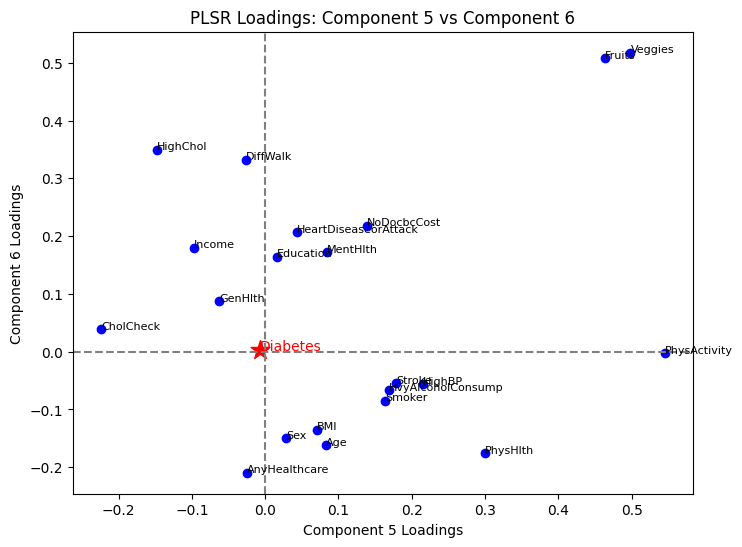

In [ ]:
# Create a loadings plot for components 5 and 6 to determine whether they are
# biologically relevant.

# get X loadings for components 5 and 6
loadings = pd.DataFrame(
    pls.x_loadings_,
    index=X.columns,
    columns=[f'Component {i+1}' for i in range(6)]
)

# get Y loadings (diabetes)
y_loadings = pd.DataFrame(
    pls.y_loadings_,
    index=['Diabetes_binary'],
    columns=[f'Component {i+1}' for i in range(6)]
)

# combine X and Y loadings
all_loadings = pd.concat([loadings, y_loadings])

plt.figure(figsize=(8, 6))

# plot feature variables in blue
plt.scatter(loadings['Component 5'], loadings['Component 6'], color='blue')
for var in loadings.index:
    plt.annotate(var, (loadings['Component 5'][var], loadings['Component 6'][var]), fontsize=8)

# plot diabetes as a red star so it stands out
plt.scatter(y_loadings['Component 5'], y_loadings['Component 6'],
            color='red', s=200, marker='*', label='Diabetes')
plt.annotate('Diabetes', (y_loadings['Component 5'][0], y_loadings['Component 6'][0]), fontsize=10, color='red')

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel('Component 5 Loadings')
plt.ylabel('Component 6 Loadings')
plt.title('PLSR Loadings: Component 5 vs Component 6')
plt.show()

The above plot shows that the diabetes loading is near 0 on both axes. Therefore, components 5 and 6 do not hold significant predictive power and can be disregarded from the final model altogether. We will proceed with 4 components.

3. Explore PLSR with 4 components

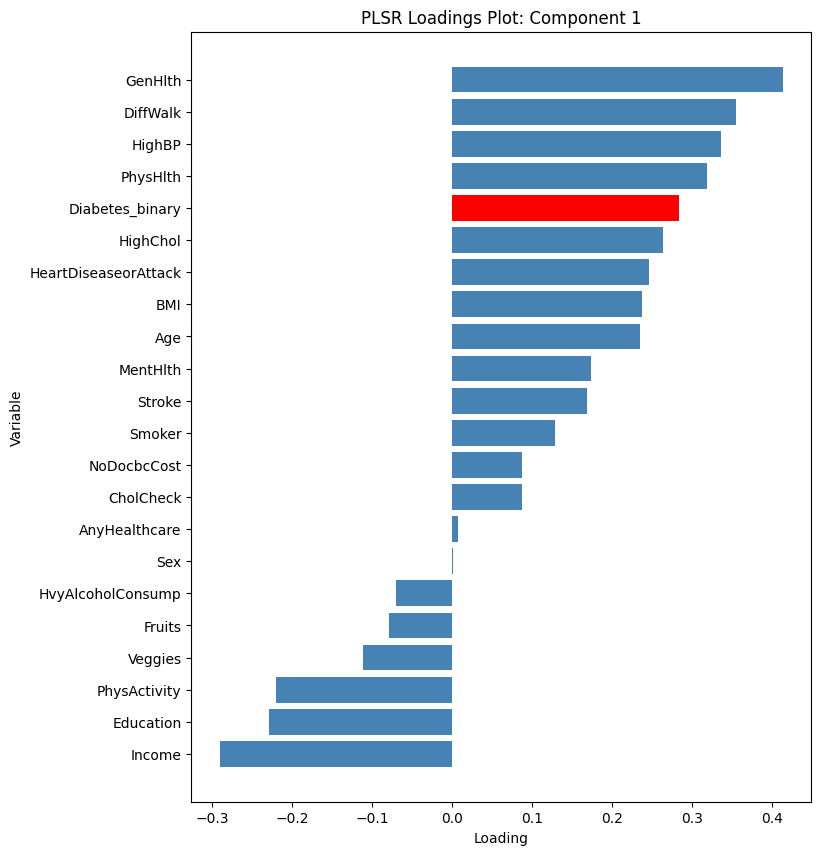

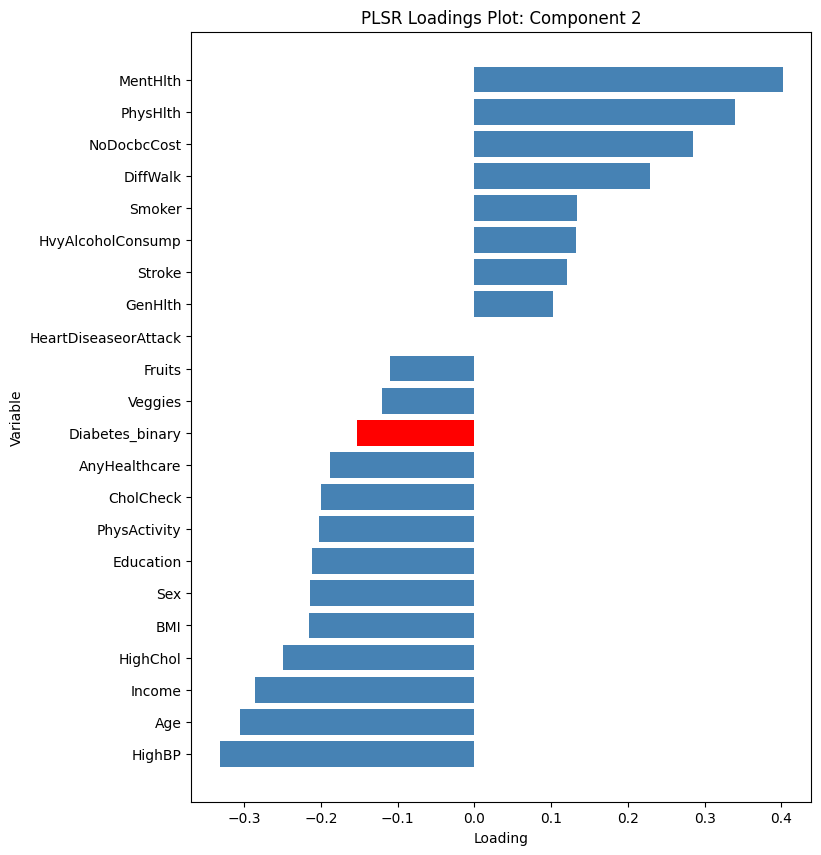

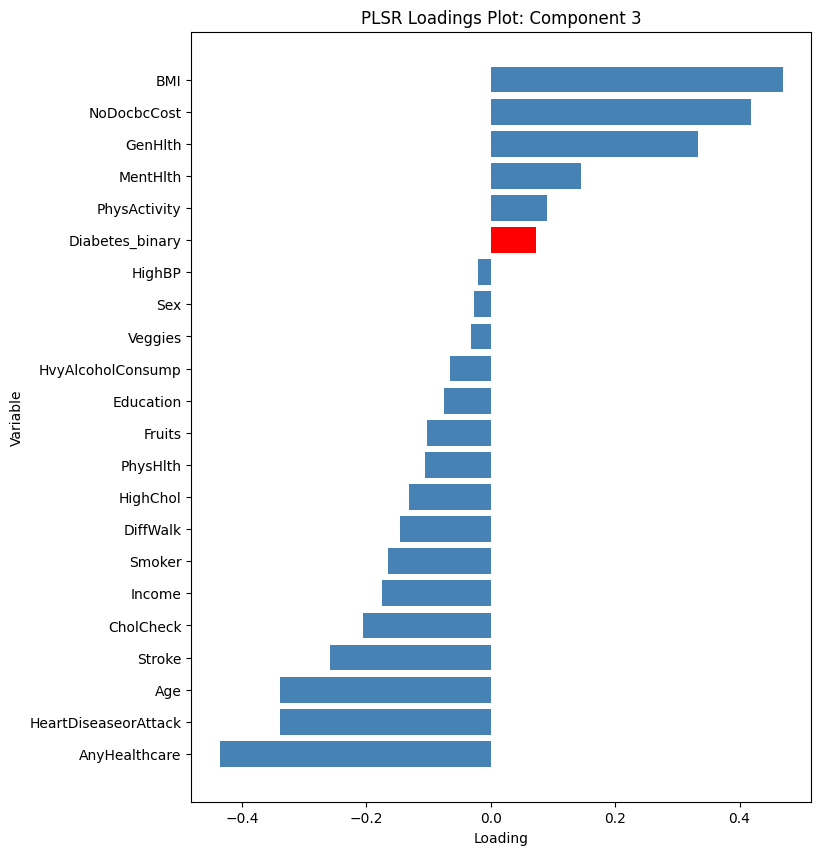

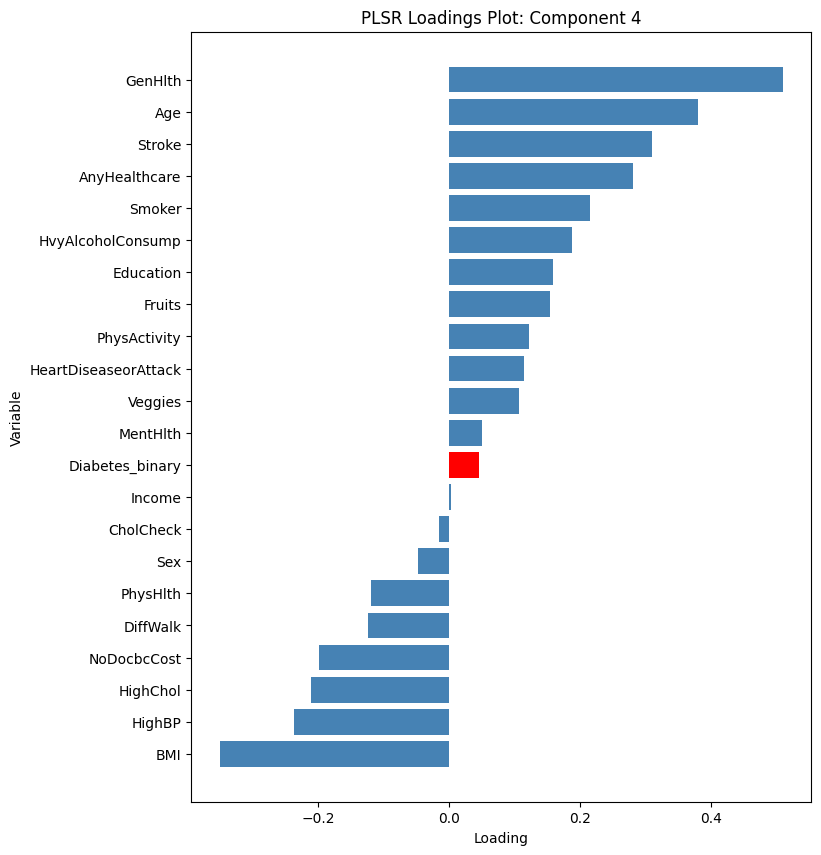

In [ ]:
# add diabetes loading to the loadings dataframe
y_loadings = pd.DataFrame(
    pls_final.y_loadings_,
    index=['Diabetes_binary'],
    columns=loadings.columns
)

all_loadings = pd.concat([loadings, y_loadings])

# plot each component
for component in all_loadings.columns:
    loading_plot = all_loadings[component].sort_values()

    colors = ['red' if var == 'Diabetes_binary' else 'steelblue' for var in loading_plot.index]

    plt.figure(figsize=(8, 10))
    plt.barh(loading_plot.index, loading_plot.values, color=colors)
    plt.xlabel("Loading")
    plt.ylabel("Variable")
    plt.title(f"PLSR Loadings Plot: {component}")
    plt.show()

Components 3 and 4 have the smallest diabetes loadings, and thus add minimal relevant information regarding the patterns in the data that are associated with diabetes status. Therefore, we will proceed by plotting the loadings plot of components 1 and 2 to observe diabetes-related patterns among our indicators.

4. PLSR loadings plot

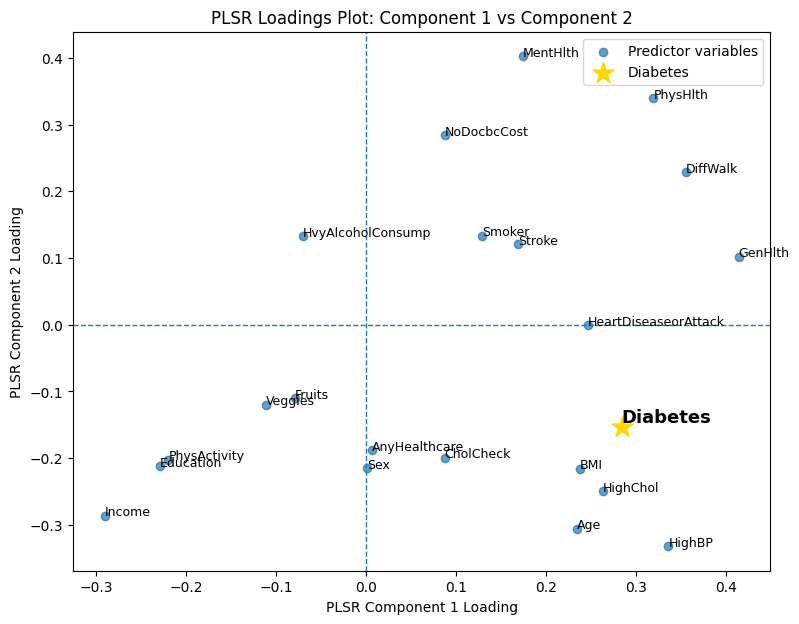

In [ ]:
# combine X and Y loadings
all_loadings = pd.concat([loadings, y_loadings])

plt.figure(figsize=(9, 7))

# Plot X variable loadings
plt.scatter(
    loadings["Component 1"],
    loadings["Component 2"],
    alpha=0.7,
    label="Predictor variables"
)

# Add variable names
for variable in loadings.index:
    plt.text(
        loadings.loc[variable, "Component 1"],
        loadings.loc[variable, "Component 2"],
        variable,
        fontsize=9
    )

# Plot Diabetes Y loading
plt.scatter(
    all_loadings.loc["Diabetes_binary", "Component 1"],
    all_loadings.loc["Diabetes_binary", "Component 2"],
    s=250,
    marker="*",
    color="gold",
    label="Diabetes"
)

plt.text(
    all_loadings.loc["Diabetes_binary", "Component 1"],
    all_loadings.loc["Diabetes_binary", "Component 2"],
    "Diabetes",
    fontsize=13,
    fontweight="bold",
    ha="left",
    va="bottom"
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("PLSR Component 1 Loading")
plt.ylabel("PLSR Component 2 Loading")
plt.title("PLSR Loadings Plot: Component 1 vs Component 2")
plt.legend()
plt.show()